# 예제 3: 설비 이상 탐지 AI (Isolation Forest)

---

## 이 예제에서 배울 것
- **비지도학습**: 정답(불량 레이블) 없이 AI가 스스로 이상을 찾는 방법
- **Isolation Forest**: 이상 탐지에 가장 널리 쓰이는 알고리즘
- **예지보전**: 설비가 고장나기 전에 징조를 미리 감지하는 방법

## 핵심 메시지
> **"정상이 어떤 것인지 배우면, 이상한 것이 무엇인지 알 수 있다."**  
> 불량 사례가 없어도 정상 데이터만으로 AI를 학습시킬 수 있습니다.

## 제조 현장 연관
- 설비 센서(진동, 온도, 전류) 데이터 → 이상 징조 조기 감지
- **예지보전**: 고장 발생 전에 경보 → 비계획 정지 방지
- 라벨링 작업 없이 바로 적용 가능한 장점

---
## 비지도학습 vs 지도학습 비교

| 구분 | 지도학습 (예제 2) | 비지도학습 (이번 예제) |
|------|-------------------|---------------------|
| 정답 필요 여부 | ✅ 필요 (불량/정상 레이블) | ❌ 불필요 |
| 학습 방법 | 정답 보고 패턴 학습 | 데이터 구조 스스로 파악 |
| 장점 | 정확한 예측 | 레이블 작업 불필요 |
| 단점 | 레이블 수집 비용 | 정확도가 낮을 수 있음 |
| 예시 | 불량 분류 AI | 이상 탐지 AI |


In [1]:
# ─────────────────────────────────────────────────────────
# 필요한 도구 불러오기
# IsolationForest: 이상 탐지 전용 알고리즘
# ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

# sklearn의 이상 탐지 전용 알고리즘
from sklearn.ensemble import IsolationForest

import warnings
warnings.filterwarnings('ignore')

print("도구 준비 완료!")

✅ 도구 준비 완료!


## STEP 1: 설비 센서 데이터 생성

실제 설비 센서 데이터를 시뮬레이션합니다:
- **정상 운전** (200일): 진동·온도·전류가 안정적
- **이상 발생** (이후 40일): 베어링 마모로 진동·온도·전류 상승

In [2]:
# ─────────────────────────────────────────────────────────
# 설비 센서 시뮬레이션 데이터 생성
# 실제 현장: PLC, SCADA, MES에서 이런 데이터가 자동 수집됨
# ─────────────────────────────────────────────────────────
np.random.seed(42)

# ── 정상 구간 데이터 (0~199일: 200일치) ───────────────────
n_정상 = 200

# np.random.normal(평균, 표준편차, 개수)
# 설비가 정상일 때의 센서값 (안정적, 변동 작음)
정상_진동 = np.random.normal(1.2, 0.2, n_정상)   # 평균 1.2 mm/s
정상_온도 = np.random.normal(72, 3, n_정상)       # 평균 72°C
정상_전류 = np.random.normal(15.5, 0.5, n_정상)  # 평균 15.5 A

# ── 이상 구간 데이터 (200~239일: 40일치) ──────────────────
n_이상 = 40

# 베어링 마모 진행 시 센서값 상승
이상_진동 = np.random.normal(2.5, 0.5, n_이상)   # 진동 크게 상승
이상_온도 = np.random.normal(85, 5, n_이상)       # 온도 상승
이상_전류 = np.random.normal(17.5, 1.0, n_이상)  # 전류 상승 (부하 증가)

# ── 전체 데이터 합치기 ──────────────────────────────────────
# np.concatenate: 두 배열을 이어 붙이기
진동 = np.concatenate([정상_진동, 이상_진동])
온도  = np.concatenate([정상_온도, 이상_온도])
전류 = np.concatenate([정상_전류, 이상_전류])

# 실제 이상 여부 (검증용 - 실제 현장에서는 이 정보가 없음!)
실제_이상 = np.array([0] * n_정상 + [1] * n_이상)  # 0=정상, 1=이상

# DataFrame으로 정리
df = pd.DataFrame({
    '날짜': pd.date_range('2024-01-01', periods=n_정상 + n_이상),
    '진동(mm/s)': 진동,
    '온도(°C)':   온도,
    '전류(A)':    전류,
    '실제이상':   실제_이상  # 검증용 (AI 학습에는 사용 안 함!)
})

print(f" 설비 센서 데이터 생성 완료: 총 {len(df)}일")
print(f"   정상 운전: {n_정상}일 | 이상 발생: {n_이상}일")
print("\n 센서 정상 범위 기준:")
print("   진동: 0.5 ~ 1.5 mm/s (경고: 2.0 이상)")
print("   온도: 65 ~ 78°C    (경고: 80 이상)")
print("   전류: 14 ~ 17 A    (경고: 17 이상)")

print("\n 데이터 미리보기 (처음 3행):")
df.head(3)

 설비 센서 데이터 생성 완료: 총 240일
   정상 운전: 200일 | 이상 발생: 40일

 센서 정상 범위 기준:
   진동: 0.5 ~ 1.5 mm/s (경고: 2.0 이상)
   온도: 65 ~ 78°C    (경고: 80 이상)
   전류: 14 ~ 17 A    (경고: 17 이상)

 데이터 미리보기 (처음 3행):


,날짜,진동(mm/s),온도(°C),전류(A),실제이상
0,2024-01-01,1.299343,73.073362,14.702786,0
1,2024-01-02,1.172347,73.682354,15.200312,0
2,2024-01-03,1.329538,75.249154,15.502622,0


## STEP 2: Isolation Forest로 이상 탐지

**Isolation Forest 원리:**
```
정상 데이터: 많이 모여 있어서 → 고립(Isolate)시키려면 여러 번 나눠야 함
이상 데이터: 드물고 멀리 있어서 → 고립시키기 쉬움 (몇 번 안 나눠도 됨)

→ "고립시키기 쉬울수록 이상 데이터"라는 원리!
```

In [3]:
# ─────────────────────────────────────────────────────────
# Isolation Forest 이상 탐지
#
# 중요: AI 학습 시 '실제 이상' 컬럼은 사용하지 않음!
# 비지도학습이므로 정답 없이 데이터 패턴만으로 이상을 찾음
# ─────────────────────────────────────────────────────────
X = df[['진동(mm/s)', '온도(°C)', '전류(A)']]  # 학습에 사용할 센서 데이터

# IsolationForest 모델 생성
# contamination: 전체 데이터 중 이상 비율 예상치
#   실제 현장에서는 0.05~0.15 (5~15%) 사이를 주로 사용
#   너무 낮으면: 이상을 놓침 / 너무 높으면: 정상도 이상으로 판단
model = IsolationForest(
    contamination=0.15,  # 전체의 15%가 이상일 것으로 예상
    random_state=42
)

print("이상 탐지 AI 학습 및 예측 중...")

# fit_predict(): 학습과 예측을 동시에 수행
# 반환값: 1 = 정상, -1 = 이상 (IsolationForest의 고유 표기)
원래_예측 = model.fit_predict(X)

# 이해하기 쉽게 변환: 1(정상)→0, -1(이상)→1
df['AI예측'] = (원래_예측 == -1).astype(int)  # -1이면 이상(1)으로 변환

print(" 이상 탐지 완료!")
print(f"   AI가 이상으로 판단한 날: {df['AI예측'].sum()}일")
print(f"   실제 이상 발생 날: {df['실제이상'].sum()}일")

이상 탐지 AI 학습 및 예측 중...
 이상 탐지 완료!
   AI가 이상으로 판단한 날: 36일
   실제 이상 발생 날: 40일


In [ ]:
# ─────────────────────────────────────────────────────────
# 성능 평가: AI가 실제 이상을 얼마나 잘 찾았나?
# ─────────────────────────────────────────────────────────
정확도 = (df['실제이상'] == df['AI예측']).mean() * 100

# 실제 이상 구간에서 AI가 맞춘 비율 (재현율)
실제이상_데이터 = df[df['실제이상'] == 1]  # 실제 이상인 행만 필터링
감지된_이상 = (실제이상_데이터['AI예측'] == 1).sum()
재현율 = 감지된_이상 / n_이상 * 100

print("=" * 50)
print("📊 AI 이상 탐지 성능")
print("=" * 50)
print(f"전체 정확도: {정확도:.1f}%")
print(f"이상 감지율 (재현율): {재현율:.0f}%")
print(f"  → 실제 이상 {n_이상}일 중 {감지된_이상}일을 감지")
print(f"  → 놓친 이상: {n_이상 - 감지된_이상}일")

## STEP 3: 시각화 — 이상 탐지 결과를 그래프로

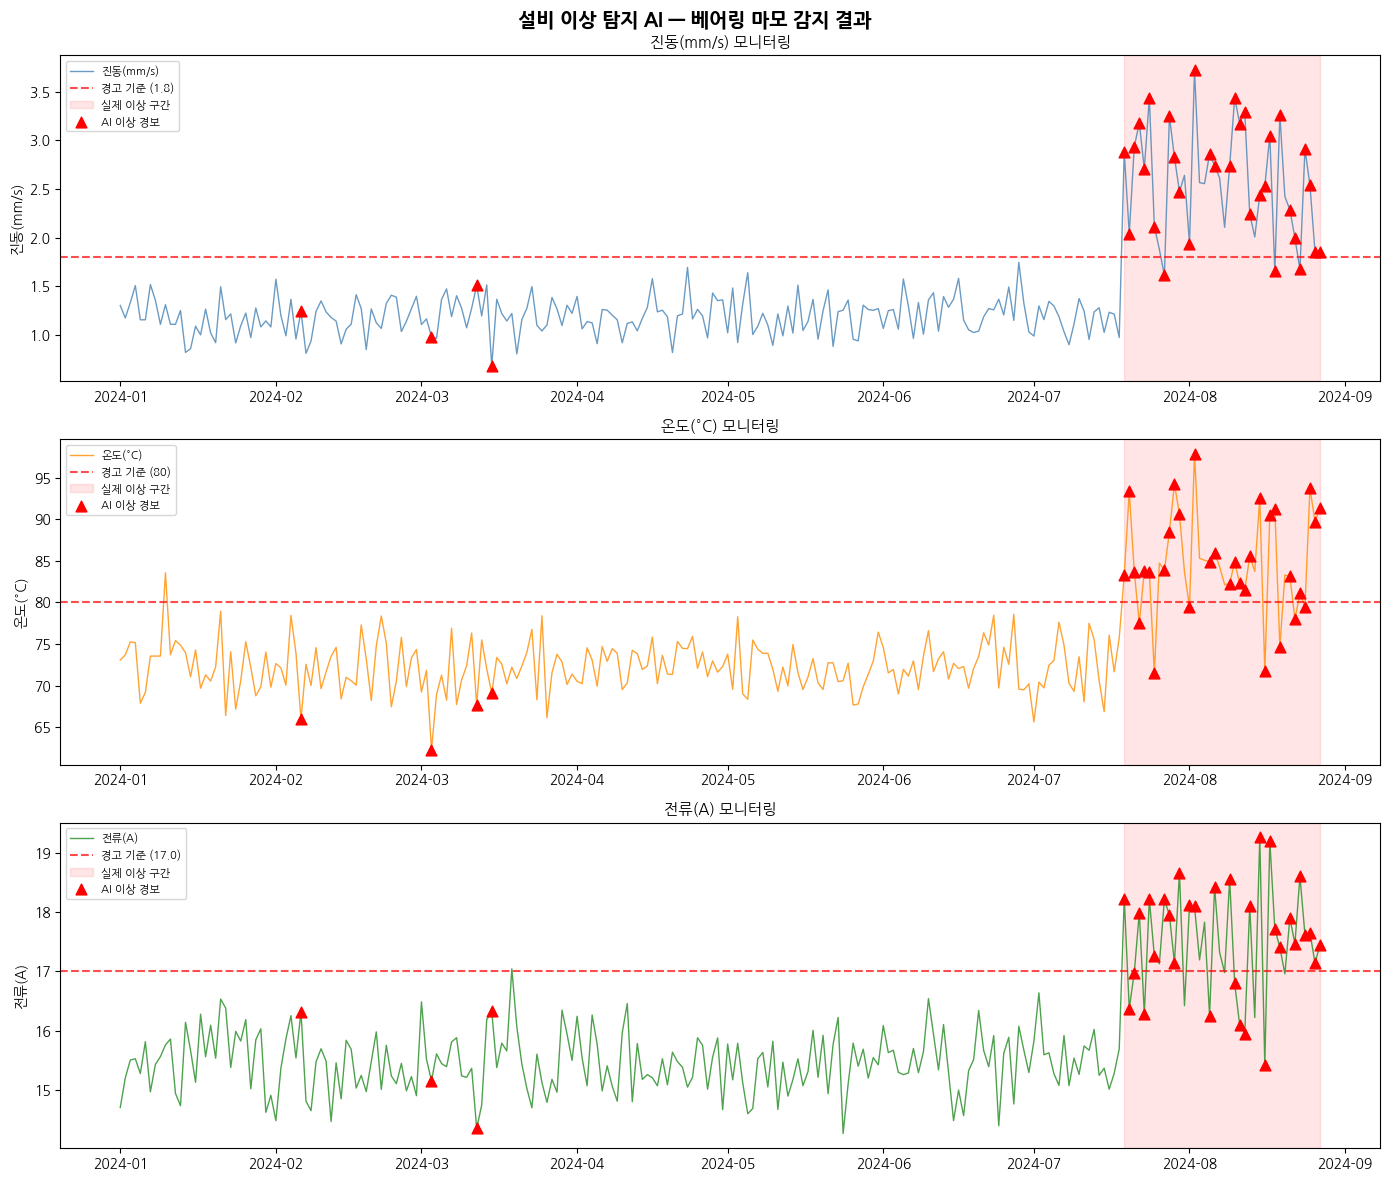


 그래프 해석:
  • 빨간 배경 구간: 실제 이상 발생 구간
  • 빨간 삼각형(▲): AI가 이상으로 판단한 날
  • 점선: 경고 기준값

  → AI가 실제 이상 구간을 대부분 감지했습니다!
  → 고장 발생 전에 경보를 받아 사전 조치 가능합니다.


In [4]:
# ─────────────────────────────────────────────────────────
# 3개 센서의 시계열 그래프 + 이상 감지 표시
# ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('설비 이상 탐지 AI — 베어링 마모 감지 결과', fontsize=14, fontweight='bold')

# 각 센서별 설정
센서들 = ['진동(mm/s)', '온도(°C)', '전류(A)']
경고기준 = [1.8, 80, 17.0]          # 각 센서의 경고 임계값
색상 = ['steelblue', 'darkorange', 'forestgreen']

for i, (센서, 기준, 색) in enumerate(zip(센서들, 경고기준, 색상)):
    # enumerate: 인덱스(i)와 값(센서, 기준, 색)을 동시에 꺼냄
    # zip: 여러 목록을 동시에 묶어서 순서대로 꺼냄

    # 센서값 시계열 그래프
    axes[i].plot(df['날짜'], df[센서],
                 color=색, linewidth=1, label=센서, alpha=0.8)

    # 경고 기준선 (수평 빨간 점선)
    axes[i].axhline(y=기준, color='red', linestyle='--',
                    alpha=0.7, label=f'경고 기준 ({기준})')

    # 이상 발생 구간 배경색 강조 (연한 빨간색)
    # axvspan: 수직 방향으로 영역을 색칠
    이상시작일 = df['날짜'][n_정상]  # 이상이 시작된 날
    마지막날 = df['날짜'].iloc[-1]    # 마지막 날 (-1 = 맨 끝)
    axes[i].axvspan(이상시작일, 마지막날,
                    alpha=0.1, color='red', label='실제 이상 구간')

    # AI가 이상으로 감지한 날을 빨간 삼각형(^)으로 표시
    이상감지일 = df[df['AI예측'] == 1]  # AI가 이상이라 한 행 필터링
    axes[i].scatter(
        이상감지일['날짜'],    # x좌표: 날짜
        이상감지일[센서],      # y좌표: 센서값
        color='red', s=60,    # s: 점 크기
        zorder=5,             # zorder: 다른 그래프 위에 표시 (숫자 클수록 위)
        marker='^',           # 삼각형 마커
        label='AI 이상 경보'
    )

    axes[i].set_title(f'{센서} 모니터링', fontsize=11)
    axes[i].set_ylabel(센서)
    axes[i].legend(loc='upper left', fontsize=8)  # loc: 범례 위치

plt.tight_layout()
plt.show()

print("\n 그래프 해석:")
print("  • 빨간 배경 구간: 실제 이상 발생 구간")
print("  • 빨간 삼각형(▲): AI가 이상으로 판단한 날")
print("  • 점선: 경고 기준값")
print("\n  → AI가 실제 이상 구간을 대부분 감지했습니다!")
print("  → 고장 발생 전에 경보를 받아 사전 조치 가능합니다.")

## STEP 4: 실제 현장 활용 시나리오

In [5]:
# ─────────────────────────────────────────────────────────
# 새로운 센서 데이터로 실시간 이상 여부 판단
# 실제 현장에서는 MES/SCADA가 이 데이터를 실시간으로 전달
# ─────────────────────────────────────────────────────────
현재_센서값 = pd.DataFrame({
    '진동(mm/s)': [1.3, 2.7, 1.1],   # 측정 1/2/3
    '온도(°C)':   [71,  88,  69],     # 측정 1/2/3
    '전류(A)':    [15.3, 18.1, 15.0] # 측정 1/2/3
})

# 학습된 모델로 현재 상태 예측
예측 = model.predict(현재_센서값)
이상여부 = (예측 == -1)  # -1이면 이상

print("=" * 55)
print("실시간 설비 이상 탐지 결과")
print("=" * 55)

상황 = ['오전 8시 측정', '오후 2시 측정', '오후 6시 측정']

for i in range(len(현재_센서값)):
    row = 현재_센서값.iloc[i]  # iloc[i]: i번째 행 가져오기
    판정 = "🔴 이상! 점검 필요" if 이상여부[i] else "🟢 정상"

    print(f"\n[{상황[i]}]")
    print(f"  진동: {row['진동(mm/s)']:.1f} mm/s | "
          f"온도: {row['온도(°C)']:.0f}°C | "
          f"전류: {row['전류(A)']:.1f} A")
    print(f"  판정: {판정}")

print("\n" + "=" * 55)
print(" 예지보전 활용 방법:")
print("  1. 이상 감지 즉시 → 보전팀에 자동 알림 전송")
print("  2. 이상 패턴 지속 → 계획 정비 일정 앞당기기")
print("  3. 누적 데이터로 → 고장 발생까지 잔여 시간 예측 (심화)")

실시간 설비 이상 탐지 결과

[오전 8시 측정]
  진동: 1.3 mm/s | 온도: 71°C | 전류: 15.3 A
  판정: 🟢 정상

[오후 2시 측정]
  진동: 2.7 mm/s | 온도: 88°C | 전류: 18.1 A
  판정: 🔴 이상! 점검 필요

[오후 6시 측정]
  진동: 1.1 mm/s | 온도: 69°C | 전류: 15.0 A
  판정: 🟢 정상

 예지보전 활용 방법:
  1. 이상 감지 즉시 → 보전팀에 자동 알림 전송
  2. 이상 패턴 지속 → 계획 정비 일정 앞당기기
  3. 누적 데이터로 → 고장 발생까지 잔여 시간 예측 (심화)


## 🎓 정리 및 핵심 포인트

### 배운 것
1. **비지도학습**: 정답 데이터 없이 AI가 스스로 이상을 찾음
2. **Isolation Forest**: 정상 데이터 패턴을 학습해서 벗어나는 것을 이상으로 판단
3. **contamination 파라미터**: 예상 이상 비율 설정 → 현장 경험으로 조정
4. **예지보전**: 고장 전 징조 감지 → 비계획 정지 예방

### 현장 도입 시 체크리스트
- [ ] 센서 데이터가 디지털로 수집되고 있는가? (수기 기록은 자동화 필요)
- [ ] 정상 운전 데이터가 최소 3~6개월 이상 쌓여 있는가?
- [ ] 이상 감지 시 알림을 받을 담당자와 프로세스가 준비되어 있는가?

### 다음 단계
**예제 4**에서는 **수요예측 AI**로 생산 계획을 데이터로 세우는 방법을 배웁니다! 📈

---
*송현그룹 mAX Academy 3기 | 예제 3/6*